In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('/content/50_Startups.csv')

In [3]:
df.head(5)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [5]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


**1st Column == X**

**Last Column == Y**

In [6]:
x=df.iloc[:,0].values
y=df.iloc[:,-1].values

In [8]:
print(x)

[165349.2  162597.7  153441.51 144372.41 142107.34 131876.9  134615.46
 130298.13 120542.52 123334.88 101913.08 100671.96  93863.75  91992.39
 119943.24 114523.61  78013.11  94657.16  91749.16  86419.7   76253.86
  78389.47  73994.56  67532.53  77044.01  64664.71  75328.87  72107.6
  66051.52  65605.48  61994.48  61136.38  63408.86  55493.95  46426.07
  46014.02  28663.76  44069.95  20229.59  38558.51  28754.33  27892.92
  23640.93  15505.73  22177.74   1000.23   1315.46      0.      542.05
      0.  ]


##Train - Test Splits

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2) #here 0.2 means test size ==20% & remaining 80% for training.

In [11]:
len(x_train)

40

In [12]:
len(x_test)

10

In [13]:
print(x_test)

[101913.08  65605.48   1315.46  64664.71  44069.95   1000.23 162597.7
  76253.86      0.   134615.46]


In [14]:
print(y_test)

[146121.95 101004.64  49490.75 107404.34  89949.14  64926.08 191792.06
 118474.03  14681.4  156122.51]


In [15]:
x_train=x_train.reshape(-1,1)
x_test=x_test.reshape(-1,1)


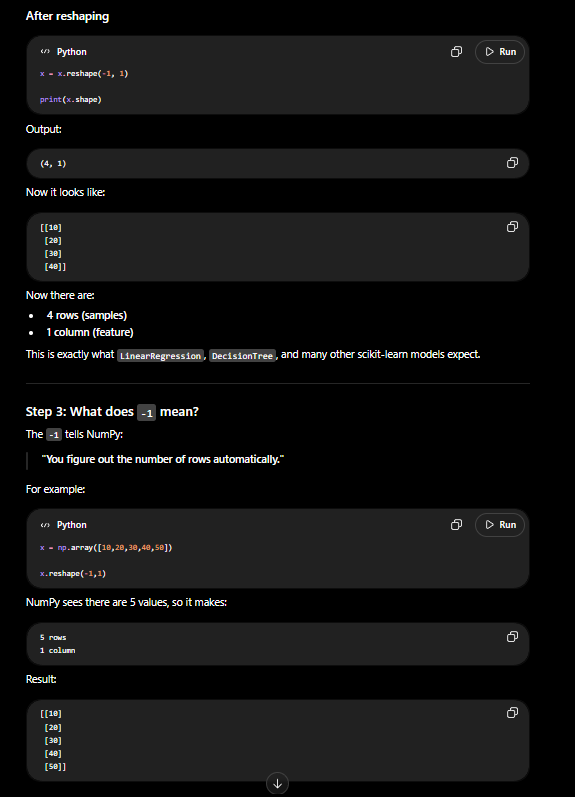

##Feature Scaling

In [17]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)


In [18]:
print(x_test)

[[ 0.60732005]
 [-0.23875348]
 [-1.73689945]
 [-0.26067618]
 [-0.74059448]
 [-1.74424524]
 [ 2.02144963]
 [ 0.00938499]
 [-1.76755353]
 [ 1.3693814 ]]


##Create Linear Regression Model

In [20]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(x_train,y_train)

LinearRegression()

##Prediction

In [21]:
y_predict=regressor.predict(x_test)

##plotting of y_test  vs Y predict

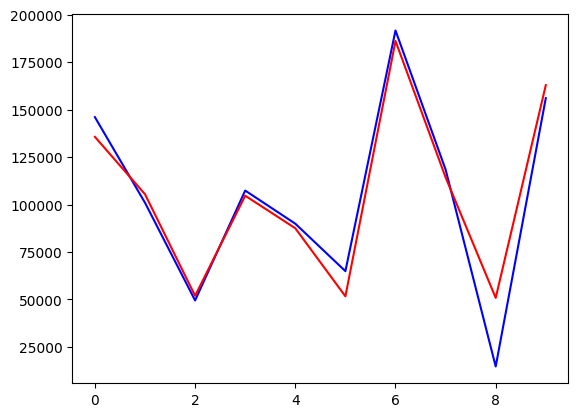

In [25]:
plt.plot(y_test,color='blue',label='test')
plt.plot(y_predict,color='red',label='predict')
plt.show()

##Regression Metrics

In [28]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [31]:
mae=mean_absolute_error(y_test,y_predict)
print(mae)

8831.211499108991


In [32]:
mse=mean_squared_error(y_test,y_predict)
print(mse)

172397103.33964115


In [33]:
print(np.sqrt(mse))


13130.007743319924


In [37]:
r2=r2_score(y_test,y_predict)
print(r2)

0.9313207879966896


In [38]:
#Calculate the adjusted-R-squared
n=x_test.shape[0]
k=x_test.shape[1]
adjusted_r2=1-(1-r2)*(n-1)/(n-1-k)
print(adjusted_r2)

0.9227358864962758
